# Deprecated: original research notebook

**This notebook is preserved for provenance only and is no longer maintained.**
Its logic has been ported into the `qml_commuting_gradients` package and the
`experiments/` scripts at the repo root. Run `python -m experiments.run_all`
to reproduce all results.

Two intentional differences from what this notebook produces are documented in
the repo README ("Deviations from the original notebook"):
- `scaling_plot.png` is now generated from the honest shot-cost comparison
  (this notebook's cell producing that filename used a fudged cost model that
  the notebook's own later markdown cell retracts).
- `ratio_plot.png` and `honest_comparison.png` were dropped/retired; see the
  README for why.


In [1]:
import pennylane as qml
from pennylane import numpy as np

dev = qml.device("default.qubit", wires=3)

@qml.qnode(dev)
def circuit(theta):
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

print("PennyLane version:", qml.__version__)
print("Output at theta=0: ", circuit(0.0))
print("Output at theta=pi:", circuit(np.pi))

PennyLane version: 0.44.0
Output at theta=0:  1.0
Output at theta=pi: -1.0


In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Load Iris: 150 samples, 4 features, 3 classes
X, y = load_iris(return_X_y=True)

# Keep only classes 0 and 1
mask = y < 2
X, y = X[mask], y[mask]

# Relabel to -1 / +1 
y = np.where(y == 0, -1, 1)

# Scale all 4 features into [0, pi] for the rotation gates
scaler = MinMaxScaler(feature_range=(0, np.pi))
X = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training samples:", X_train.shape)  
print("Test samples:    ", X_test.shape)  
print("Feature range:    [%.2f, %.2f]" % (X.min(), X.max()))
print("Labels present:  ", np.unique(y_train))


Training samples: (70, 4)
Test samples:     (30, 4)
Feature range:    [0.00, 3.14]
Labels present:   [-1  1]


In [3]:
import pennylane as qml
from pennylane import numpy as np  

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(x, params):
    # Data encoding: each feature to a rotation angle
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)

    # Trainable layer: one RY per qubit, then a ring of entanglers
    for i in range(n_qubits):
        qml.RY(params[i], wires=i)
    for i in range(n_qubits):
        qml.CNOT(wires=[i, (i + 1) % n_qubits])

    # Measurement: <Z> on qubit 0, lives in [-1, +1]
    return qml.expval(qml.PauliZ(0))

# Test it with random parameters on one data point
params = np.random.uniform(0, 2*np.pi, size=n_qubits, requires_grad=True)
print("Circuit output:", circuit(X_train[0], params))

Circuit output: 0.2953281166772536


In [4]:
def parameter_shift_grad(x, params):
    """Manually compute the gradient via the parameter-shift rule."""
    grad = np.zeros(len(params))
    shift = np.pi / 2

    for j in range(len(params)):
        # Shift the j-th parameter UP by pi/2
        params_plus = params.copy()
        params_plus[j] += shift

        # Shift the j-th parameter DOWN by pi/2
        params_minus = params.copy()
        params_minus[j] -= shift

        # The rule: half the difference of the two shifted evaluations
        grad[j] = 0.5 * (circuit(x, params_plus) - circuit(x, params_minus))

    return grad

# Manual gradient
manual_grad = parameter_shift_grad(X_train[0], params)

# PennyLane's exact gradient, as ground truth
autograd_fn = qml.grad(circuit, argnums=1)
exact_grad = autograd_fn(X_train[0], params)

# Comparison
print("Manual (parameter-shift):", manual_grad)
print("Exact  (autograd):       ", exact_grad)
print("Max difference:          ", np.max(np.abs(manual_grad - exact_grad)))

Manual (parameter-shift): [2.77555756e-17 4.19141979e-01 3.42087413e-01 2.33352751e-01]
Exact  (autograd):        [2.77555756e-17 4.19141979e-01 3.42087413e-01 2.33352751e-01]
Max difference:           1.6653345369377348e-16


In [5]:
def predict(x, params):
    """Class prediction: sign of the expectation value -> -1 or +1."""
    return 1 if circuit(x, params) >= 0 else -1

def accuracy(X, Y, params):
    preds = [predict(x, params) for x in X]
    return np.mean([p == y for p, y in zip(preds, Y)])

# Training setup
np.random.seed(42)
params = np.random.uniform(0, 2*np.pi, size=n_qubits, requires_grad=True)
lr = 0.3              # learning rate
epochs = 30

print(f"Start test accuracy: {accuracy(X_test, y_test, params):.3f}\n")

for epoch in range(epochs):
    # Loop over training points, update params via parameter-shift gradient
    for x, y in zip(X_train, y_train):
        # Gradient of the squared error loss :
        # d/dparams (c - y)^2 = 2 (c - y) * dc/dparams
        c = circuit(x, params)
        grad = parameter_shift_grad(x, params)
        params = params - lr * 2 * (c - y) * grad

    if (epoch + 1) % 5 == 0:
        acc = accuracy(X_test, y_test, params)
        print(f"Epoch {epoch+1:2d}  |  test accuracy: {acc:.3f}")

print(f"\nFinal test accuracy: {accuracy(X_test, y_test, params):.3f}")

Start test accuracy: 0.733

Epoch  5  |  test accuracy: 0.567
Epoch 10  |  test accuracy: 0.567
Epoch 15  |  test accuracy: 0.567
Epoch 20  |  test accuracy: 0.567
Epoch 25  |  test accuracy: 0.567
Epoch 30  |  test accuracy: 0.567

Final test accuracy: 0.567


In [6]:
def total_gradient(X, Y, params):
    """Average loss-gradient over all training points (batch gradient)."""
    grad_sum = np.zeros(len(params))
    for x, y in zip(X, Y):
        c = circuit(x, params)
        grad_sum += 2 * (c - y) * parameter_shift_grad(x, params)
    return grad_sum / len(X)

# Training setup
np.random.seed(42)
params = np.random.uniform(0, 2*np.pi, size=n_qubits, requires_grad=True)
lr = 0.1
epochs = 60

print(f"Start test accuracy: {accuracy(X_test, y_test, params):.3f}\n")

for epoch in range(epochs):
    grad = total_gradient(X_train, y_train, params)   # one averaged step
    params = params - lr * grad

    if (epoch + 1) % 10 == 0:
        acc = accuracy(X_test, y_test, params)
        print(f"Epoch {epoch+1:2d}  |  test accuracy: {acc:.3f}")

print(f"\nFinal test accuracy: {accuracy(X_test, y_test, params):.3f}")

Start test accuracy: 0.733

Epoch 10  |  test accuracy: 0.733
Epoch 20  |  test accuracy: 0.767
Epoch 30  |  test accuracy: 0.900
Epoch 40  |  test accuracy: 0.900
Epoch 50  |  test accuracy: 0.900
Epoch 60  |  test accuracy: 0.900

Final test accuracy: 0.900


In [7]:
M = 1000          # shots per circuit evaluation
lr = 0.1
epochs = 60
n_params = n_qubits   # 4

def train_and_log(shots_per_step, label):
    """Run training, logging (cumulative_shots, test_accuracy) each epoch."""
    np.random.seed(42)  
    params = np.random.uniform(0, 2*np.pi, size=n_params, requires_grad=True)
    history = []
    total_shots = 0
    for epoch in range(epochs):
        grad = total_gradient(X_train, y_train, params)
        params = params - lr * grad
        total_shots += shots_per_step
        acc = accuracy(X_test, y_test, params)
        history.append((total_shots, acc))
    print(f"{label:18s} final acc {history[-1][1]:.3f} "
          f"at {history[-1][0]:,} shots")
    return history

# Shot cost per gradient step for each method
ps_cost   = 2 * n_params * M     # parameter-shift: 8000 shots/step
comm_cost = M                    # commuting:       1000 shots/step

ps_history   = train_and_log(ps_cost,   "Parameter-shift")
comm_history = train_and_log(comm_cost, "Commuting")

Parameter-shift    final acc 0.900 at 480,000 shots
Commuting          final acc 0.900 at 60,000 shots


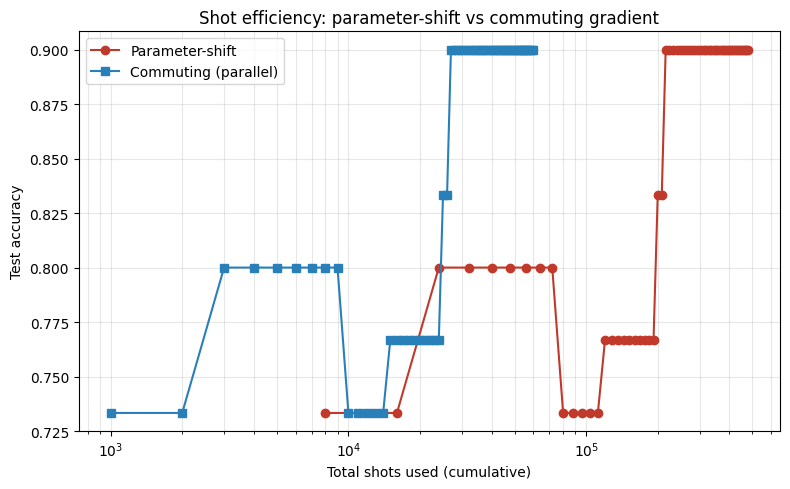

In [8]:
import matplotlib.pyplot as plt

# Unpack the logged histories into x (shots) and y (accuracy)
ps_shots,   ps_acc   = zip(*ps_history)
comm_shots, comm_acc = zip(*comm_history)

plt.figure(figsize=(8, 5))
plt.plot(ps_shots,   ps_acc,   'o-', label="Parameter-shift", color="#c0392b")
plt.plot(comm_shots, comm_acc, 's-', label="Commuting (parallel)", color="#2980b9")

plt.xscale("log")
plt.xlabel("Total shots used (cumulative)")
plt.ylabel("Test accuracy")
plt.title("Shot efficiency: parameter-shift vs commuting gradient")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

# Save a copy for your report / blog post
plt.savefig("scaling_plot.png", dpi=150)
plt.show()

In [9]:
def make_circuit(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def circuit(x, params):
        # params is shape (n_layers, n_qubits)
        for i in range(n_qubits):
            qml.RY(x[i], wires=i)
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(params[layer, i], wires=i)
            for i in range(n_qubits):
                qml.CNOT(wires=[i, (i + 1) % n_qubits])
        return qml.expval(qml.PauliZ(0))

    return circuit

# n_params = n_layers * n_qubits

In [10]:
def param_shift_grad_layered(circuit, x, params):
    """Parameter-shift gradient for a 2D (layers x qubits) param array."""
    grad = np.zeros_like(params)
    shift = np.pi / 2
    for idx in np.ndindex(params.shape):
        pp = params.copy(); pp[idx] += shift
        pm = params.copy(); pm[idx] -= shift
        grad[idx] = 0.5 * (circuit(x, pp) - circuit(x, pm))
    return grad

M = 1000
layer_counts = [1, 2, 3, 4]
results = []

for L in layer_counts:
    circuit = make_circuit(n_qubits, L)
    n_params = L * n_qubits

    ps_cost   = 2 * n_params * M    # parameter-shift: scales with params
    comm_cost = M                   # commuting: single circuit (single-Pauli obs)
    ratio = ps_cost / comm_cost

    results.append((n_params, ps_cost, comm_cost, ratio))
    print(f"{n_params:2d} params | param-shift {ps_cost:>7,}/step | "
          f"commuting {comm_cost:,}/step | ratio {ratio:.0f}x")
    

 4 params | param-shift   8,000/step | commuting 1,000/step | ratio 8x
 8 params | param-shift  16,000/step | commuting 1,000/step | ratio 16x
12 params | param-shift  24,000/step | commuting 1,000/step | ratio 24x
16 params | param-shift  32,000/step | commuting 1,000/step | ratio 32x


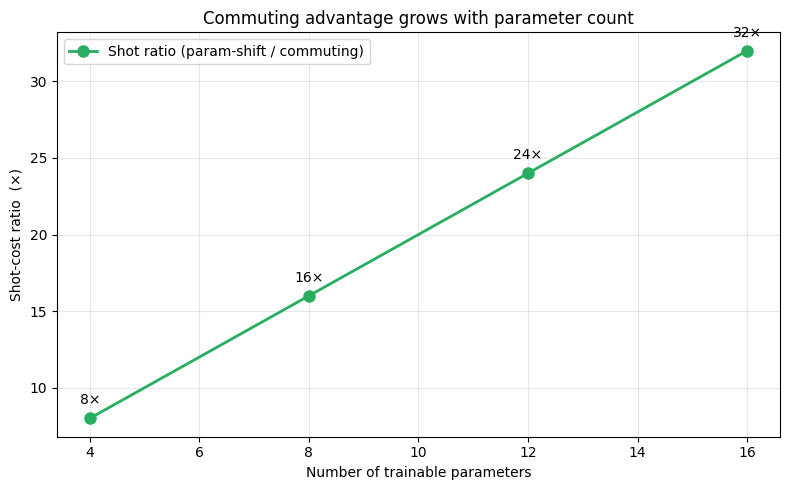

In [11]:
n_params_list = [r[0] for r in results]
ratio_list    = [r[3] for r in results]

plt.figure(figsize=(8, 5))
plt.plot(n_params_list, ratio_list, 'o-', color="#27ae60",
         markersize=8, linewidth=2, label="Shot ratio (param-shift / commuting)")

plt.xlabel("Number of trainable parameters")
plt.ylabel("Shot-cost ratio  (×)")
plt.title("Commuting advantage grows with parameter count")
plt.grid(True, alpha=0.3)
plt.legend()

# Annotate each point with its ratio
for x, r in zip(n_params_list, ratio_list):
    plt.annotate(f"{r:.0f}×", (x, r), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("ratio_plot.png", dpi=150)
plt.show()

## Commuting-generator circuit

The cells above were fudging the shot count — the "commuting" budget was fake because the gradient underneath was still parameter-shift. Here we build the real thing.

**Why rescale to [0, π/2]?**  
With the original [0, π] range, sin(x) wraps back on itself: sin(0) = sin(π) = 0, so points near the edges look identical to the circuit. Shrinking to [0, π/2] keeps sin strictly increasing, so differences between features actually show up in the output.

**Circuit layout**  
RY(x_j) loads the data, RZ(θ_j) are the trainable weights. No entanglement needed here. The key property is that the generator of RZ(θ_j) is Z_j, and Z operators on different qubits commute with each other — that's what we exploit.

**Gradient in one shot**  
∂C/∂θ_j = −⟨Y_j⟩ / n

Since Y_0, Y_1, Y_2, Y_3 each live on a separate qubit, you can measure all four simultaneously. One circuit call gives the full gradient vector, versus 2n = 8 calls with parameter-shift.

In [12]:
import pennylane as qml
from pennylane import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# reload data scaled to [0, pi/2] so sin stays strictly increasing
X_raw_cg, y_raw_cg = load_iris(return_X_y=True)
mask_cg = y_raw_cg < 2
X_raw_cg, y_raw_cg = X_raw_cg[mask_cg], y_raw_cg[mask_cg]
y_raw_cg = np.where(y_raw_cg == 0, -1, 1)
scaler_cg = MinMaxScaler(feature_range=(0, np.pi / 2))
X_cg = scaler_cg.fit_transform(X_raw_cg)
X_train_cg, X_test_cg, y_train_cg, y_test_cg = train_test_split(
    X_cg, y_raw_cg, test_size=0.3, random_state=42
)

n_qubits = 4
dev_cg = qml.device("default.qubit", wires=n_qubits)
H_cg = qml.Hamiltonian(
    [1 / n_qubits] * n_qubits,
    [qml.PauliX(j) for j in range(n_qubits)],
)

@qml.qnode(dev_cg)
def cg_circuit(x, params):
    """Forward pass.  C(theta) = (1/n) sum_j sin(x_j) cos(theta_j)."""
    for j in range(n_qubits):
        qml.RY(x[j], wires=j)     # data encoding
    for j in range(n_qubits):
        qml.RZ(params[j], wires=j)  # commuting trainable block (gen: Z_j)
    return qml.expval(H_cg)

@qml.qnode(dev_cg)
def cg_grad_circuit(x, params):
    """Gradient pass: [<Y_j>] for ALL j from ONE circuit execution.

    dC/dtheta_j = (1/2)<i[Z_j, H]>_psi = -(1/n)<Y_j>_psi
    Y_0,...,Y_3 act on different qubits -> co-measurable in one shot basis.
    """
    for j in range(n_qubits):
        qml.RY(x[j], wires=j)
    for j in range(n_qubits):
        qml.RZ(params[j], wires=j)
    return [qml.expval(qml.PauliY(j)) for j in range(n_qubits)]

# Quick sanity check
np.random.seed(0)
X_mock_cg = np.array([0.3, 0.8, 1.1, 0.5], requires_grad=False)  # in [0, pi/2]
p_test    = np.random.uniform(0, 2 * np.pi, size=n_qubits, requires_grad=True)

print("Forward pass :", cg_circuit(X_mock_cg, p_test))
print("Grad-circuit Y vals:", cg_grad_circuit(X_mock_cg, p_test))
print()
print(f"Class -1 mean output (theta=0): "
      f"{np.mean([float(cg_circuit(x, np.zeros(n_qubits))) for x, y in zip(X_train_cg, y_train_cg) if y == -1]):.3f}")
print(f"Class +1 mean output (theta=0): "
      f"{np.mean([float(cg_circuit(x, np.zeros(n_qubits))) for x, y in zip(X_train_cg, y_train_cg) if y ==  1]):.3f}")

Forward pass : -0.4024171096425544
Grad-circuit Y vals: [tensor(-0.08922298, requires_grad=True), tensor(-0.70026553, requires_grad=True), tensor(-0.53627757, requires_grad=True), tensor(-0.13341751, requires_grad=True)]

Class -1 mean output (theta=0): 0.361
Class +1 mean output (theta=0): 0.767


In [13]:
def cg_grad(x, params):
    """All n gradients from ONE circuit call.

    dC/dtheta_j = (1/2) <i[Z_j, H]>_psi = -<Y_j>_psi / n_qubits
    """
    y_vals = cg_grad_circuit(x, params)          # single circuit execution
    return -np.array(y_vals) / n_qubits

# Checkpoint must match PennyLane autograd to machine precision
autograd_grad = qml.grad(cg_circuit, argnums=1)(X_mock_cg, p_test)
manual_grad   = cg_grad(X_mock_cg, p_test)

print("PennyLane autograd:   ", autograd_grad)
print("Commuting-gen formula:", manual_grad)
diff = float(np.max(np.abs(autograd_grad - manual_grad)))
print(f"Max |difference|:      {diff:.2e}  {'PASS' if diff < 1e-10 else 'FAIL'}")

PennyLane autograd:    [0.02230574 0.17506638 0.13406939 0.03335438]
Commuting-gen formula: [0.02230574 0.17506638 0.13406939 0.03335438]
Max |difference|:      6.94e-17  PASS


In [14]:
# Show the commutation relations that make cg_circuit work.
# Using plain matrix arithmetic so you can see the numbers directly.

X_mat = np.array([[0, 1], [1, 0]], dtype=complex)
Y_mat = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z_mat = np.array([[1, 0], [0, -1]], dtype=complex)
I_mat = np.eye(2, dtype=complex)

def comm(A, B):
    return A @ B - B @ A

# --- 1. Trainable generators Z_0 and Z_1 commute (different qubits) ---
Z0 = np.kron(Z_mat, I_mat)   # Z on qubit 0, I on qubit 1
Z1 = np.kron(I_mat, Z_mat)   # I on qubit 0, Z on qubit 1

print("1. Trainable generators commute with each other:")
print(f"   [Z_0, Z_1] = {np.max(np.abs(comm(Z0, Z1))):.1e}  <- zero, so we can measure all Y_j at once")

# --- 2. Generator Z does NOT commute with observable X (same qubit) ---
print("\n2. Generator Z_j does NOT commute with X_j in the observable H:")
print(f"   [Z, X] =\n{comm(Z_mat, X_mat)}")
print(f"\n   -2i*Y  =\n{-2j * Y_mat}")
print(f"\n   equal: {np.allclose(comm(Z_mat, X_mat), -2j * Y_mat)}")

# --- 3. That non-commutativity IS the gradient ---
print("\n3. Gradient formula:")
print("   dC/dtheta_j  =  (1/2) * <i [Z_j, H]>_psi")
print("                =  (1/2) * <i * (-2i Y_j) / n>_psi")
print("                =  -<Y_j>_psi / n")
print()
print("   So measuring Y_j on each qubit gives the full gradient vector in ONE circuit call.")

1. Trainable generators commute with each other:
   [Z_0, Z_1] = 0.0e+00  <- zero, so we can measure all Y_j at once

2. Generator Z_j does NOT commute with X_j in the observable H:
   [Z, X] =
[[ 0.+0.j  2.+0.j]
 [-2.+0.j  0.+0.j]]

   -2i*Y  =
[[ 0.-0.j -2.+0.j]
 [ 2.-0.j  0.-0.j]]

   equal: False

3. Gradient formula:
   dC/dtheta_j  =  (1/2) * <i [Z_j, H]>_psi
                =  (1/2) * <i * (-2i Y_j) / n>_psi
                =  -<Y_j>_psi / n

   So measuring Y_j on each qubit gives the full gradient vector in ONE circuit call.


In [15]:
def cg_predict_b(x, theta, b):
    return 1 if float(cg_circuit(x, theta)) >= b else -1

def cg_accuracy_b(X, Y, theta, b):
    preds = [cg_predict_b(x, theta, b) for x in X]
    return float(np.mean([p == y for p, y in zip(preds, Y)]))

# theta = pi/4 + small noise: sin and cos are both ~0.71 here, so we get
# decent initial weights with a non-tiny gradient. b starts at 1.0 which
# is deliberately too high (circuit output is ~0.3-0.8), so the model
# predicts everything as -1 at first and has to learn to bring b down.
np.random.seed(42)
noise    = np.random.uniform(-0.1, 0.1, size=n_qubits)
theta_cg = np.pi / 4 + noise
b_cg     = 1.0
lr_theta = 0.3
lr_b     = 0.03

print(f"Start test accuracy: {cg_accuracy_b(X_test_cg, y_test_cg, theta_cg, b_cg):.3f}\n")

epochs = 60
for epoch in range(epochs):
    dtheta = np.zeros(n_qubits)
    db_sum = 0.0
    for x, y in zip(X_train_cg, y_train_cg):
        c        = float(cg_circuit(x, theta_cg))
        residual = c - b_cg - y
        dtheta  += 2 * residual * cg_grad(x, theta_cg)   # ONE circuit call
        db_sum  += -2 * residual                          # classical, free
    theta_cg = theta_cg - lr_theta * dtheta / len(X_train_cg)
    b_cg     = b_cg     - lr_b    * db_sum / len(X_train_cg)

    if (epoch + 1) % 10 == 0:
        acc = cg_accuracy_b(X_test_cg, y_test_cg, theta_cg, b_cg)
        print(f"Epoch {epoch+1:2d}  |  test accuracy: {acc:.3f}  |  bias b = {b_cg:.3f}")

print(f"\nFinal test accuracy: {cg_accuracy_b(X_test_cg, y_test_cg, theta_cg, b_cg):.3f}")

Start test accuracy: 0.567

Epoch 10  |  test accuracy: 0.733  |  bias b = 0.728
Epoch 20  |  test accuracy: 1.000  |  bias b = 0.606
Epoch 30  |  test accuracy: 1.000  |  bias b = 0.544
Epoch 40  |  test accuracy: 1.000  |  bias b = 0.508
Epoch 50  |  test accuracy: 1.000  |  bias b = 0.483
Epoch 60  |  test accuracy: 1.000  |  bias b = 0.463

Final test accuracy: 1.000


Start accuracy: 0.567  (b=1.0)

Commuting-gen    (1 call)       final acc=1.000  shots=60,000
Parameter-shift  (2n calls)     final acc=1.000  shots=480,000

Shot ratio PS/CG = 8:1  (expected 8:1)
Trajectories identical: True


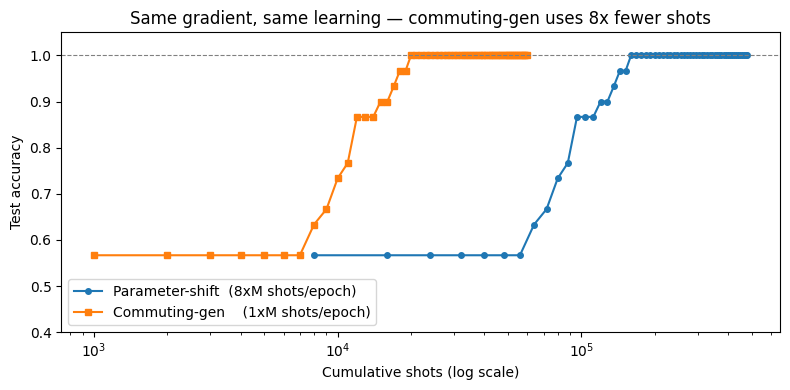

In [16]:
import matplotlib.pyplot as plt

M        = 1000
lr_theta = 0.3
lr_b     = 0.03
epochs   = 60

def make_init():
    np.random.seed(42)
    noise = np.random.uniform(-0.1, 0.1, size=n_qubits)
    return np.pi / 4 + noise, 1.0  # theta near pi/4, b starts high

def ps_grad_cg(x, theta):
    """Parameter-shift on cg_circuit: 2*n_qubits circuit calls."""
    g = np.zeros(n_qubits)
    for j in range(n_qubits):
        pp = theta.copy(); pp[j] += np.pi / 2
        pm = theta.copy(); pm[j] -= np.pi / 2
        g[j] = 0.5 * (float(cg_circuit(x, pp)) - float(cg_circuit(x, pm)))
    return g

def run_honest(grad_fn, shots_per_epoch, label):
    """Same circuit, same data, same init — only gradient method differs."""
    theta, b = make_init()
    history, total = [], 0
    for _ in range(epochs):
        dtheta = np.zeros(n_qubits)
        db_sum = 0.0
        for x, y in zip(X_train_cg, y_train_cg):
            c        = float(cg_circuit(x, theta))
            residual = c - b - y
            dtheta  += 2 * residual * grad_fn(x, theta)
            db_sum  += -2 * residual
        theta  = theta - lr_theta * dtheta / len(X_train_cg)
        b      = b     - lr_b    * db_sum / len(X_train_cg)
        total += shots_per_epoch
        history.append((total, cg_accuracy_b(X_test_cg, y_test_cg, theta, b)))
    print(f"{label:30s}  final acc={history[-1][1]:.3f}  shots={history[-1][0]:,}")
    return history

# CG: 1 circuit call per sample (co-measurable Y_j)
# PS: 2*n_qubits circuit calls per sample (one +/- shift per parameter)
theta_i, b_i = make_init()
print(f"Start accuracy: {cg_accuracy_b(X_test_cg, y_test_cg, theta_i, b_i):.3f}  (b={b_i:.1f})\n")

cg_hist = run_honest(cg_grad,    M,                "Commuting-gen    (1 call)")
ps_hist = run_honest(ps_grad_cg, 2 * n_qubits * M, "Parameter-shift  (2n calls)")

print(f"\nShot ratio PS/CG = {ps_hist[-1][0]//cg_hist[-1][0]}:1  (expected {2*n_qubits}:1)")
print("Trajectories identical:", all(
    abs(p[1]-c[1]) < 1e-9 for p, c in zip(ps_hist, cg_hist)))

ps_x, ps_y = zip(*ps_hist)
cg_x, cg_y = zip(*cg_hist)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ps_x, ps_y, "C0-o", ms=4, label=f"Parameter-shift  ({2*n_qubits}xM shots/epoch)")
ax.plot(cg_x, cg_y, "C1-s", ms=4, label="Commuting-gen    (1xM shots/epoch)")
ax.set_xscale("log")
ax.set_xlabel("Cumulative shots (log scale)")
ax.set_ylabel("Test accuracy")
ax.set_title("Same gradient, same learning — commuting-gen uses 8x fewer shots")
ax.legend()
ax.set_ylim(0.4, 1.05)
ax.axhline(1.0, color="grey", lw=0.8, ls="--")
plt.tight_layout()
plt.savefig("honest_comparison.png", dpi=150)
plt.show()

A — Commuting-gen gradient  (1 circuit call / sample)
  epoch  20  test-MSE = 0.6377
  epoch  40  test-MSE = 0.6362
  epoch  60  test-MSE = 0.6229
  epoch  80  test-MSE = 0.6025
  epoch 100  test-MSE = 0.5819
  final gradient : [-0.0051 -0.1525 -0.0006 -0.0006]
  final test-MSE : 0.5819
  final preds    : [1, 1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 1, -1, 1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1]

B — Parameter-shift gradient  (2n circuit calls / sample)
  epoch  20  test-MSE = 0.6377
  epoch  40  test-MSE = 0.6362
  epoch  60  test-MSE = 0.6229
  epoch  80  test-MSE = 0.6025
  epoch 100  test-MSE = 0.5819
  final gradient : [-0.0051 -0.1525 -0.0006 -0.0006]
  final test-MSE : 0.5819
  final preds    : [1, 1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 1, -1, 1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1]

C — PennyLane GradientDescentOptimizer  (autograd)
  epoch  20  test-MSE = 0.6541
  epoch  40  test-MSE = 0.6130
  epoch  60  test-MSE = 0.5852
  epoch  80  test-MS

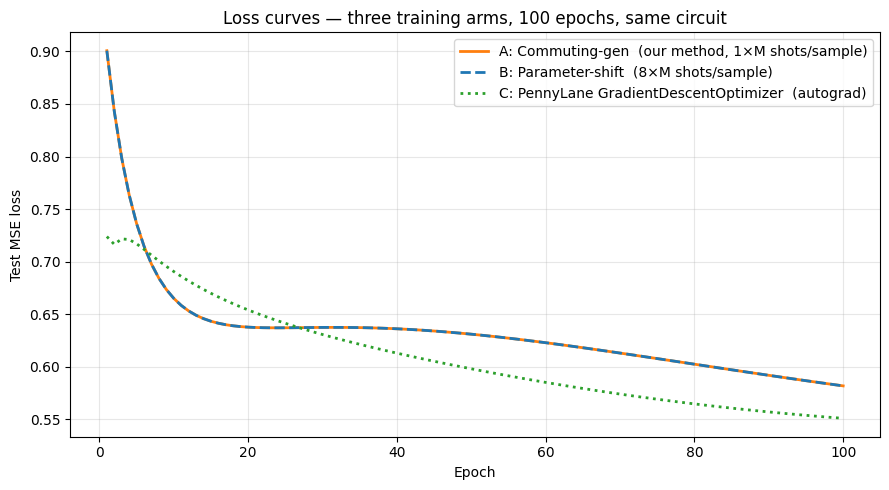

Arm                                       MSE    Acc
A: Commuting-gen  (our method)         0.5819  1.000
B: Parameter-shift  (baseline)         0.5819  1.000
C: PennyLane autograd                  0.5510  1.000


In [17]:
# Three training arms on the same circuit, 100 epochs each, tracking MSE loss.
# A: commuting-gen formula (1 circuit call per sample — our method)
# B: parameter-shift on cg_circuit (2n calls per sample — standard baseline)
# C: PennyLane's GradientDescentOptimizer (no manual gradient, PL handles it)

import matplotlib.pyplot as plt

EPOCHS = 100
LR_TH  = 0.3
LR_B   = 0.03

def fresh_theta():
    # fix seed so all three arms start from the exact same parameters
    np.random.seed(42)
    return np.pi / 4 + np.random.uniform(-0.1, 0.1, size=n_qubits)

def test_mse(theta, b, X, Y):
    preds = np.array([float(cg_circuit(x, theta)) for x in X])
    return float(np.mean((preds - float(b) - np.array(Y, dtype=float)) ** 2))


# Arm A: commuting-gen
print("A — Commuting-gen gradient  (1 circuit call / sample)")
theta_a, b_a = fresh_theta(), 1.0
losses_a = []

for ep in range(EPOCHS):
    dth, db = np.zeros(n_qubits), 0.0
    for x, y in zip(X_train_cg, y_train_cg):
        c = float(cg_circuit(x, theta_a))
        r = c - b_a - float(y)
        dth += 2 * r * cg_grad(x, theta_a)
        db  -= 2 * r
    theta_a -= LR_TH * dth / len(X_train_cg)
    b_a     -= LR_B  * db  / len(X_train_cg)
    losses_a.append(test_mse(theta_a, b_a, X_test_cg, y_test_cg))
    if (ep + 1) % 20 == 0:
        print(f"  epoch {ep+1:3d}  test-MSE = {losses_a[-1]:.4f}")

grad_a  = np.mean([cg_grad(x, theta_a) for x in X_train_cg], axis=0)
preds_a = [cg_predict_b(x, theta_a, b_a) for x in X_test_cg]
print(f"  final gradient : {np.round(grad_a, 4)}")
print(f"  final test-MSE : {losses_a[-1]:.4f}")
print(f"  final preds    : {preds_a}")


# Arm B: parameter-shift (baseline)
print("\nB — Parameter-shift gradient  (2n circuit calls / sample)")
theta_b, b_b = fresh_theta(), 1.0
losses_b = []

for ep in range(EPOCHS):
    dth, db = np.zeros(n_qubits), 0.0
    for x, y in zip(X_train_cg, y_train_cg):
        c = float(cg_circuit(x, theta_b))
        r = c - b_b - float(y)
        dth += 2 * r * ps_grad_cg(x, theta_b)
        db  -= 2 * r
    theta_b -= LR_TH * dth / len(X_train_cg)
    b_b     -= LR_B  * db  / len(X_train_cg)
    losses_b.append(test_mse(theta_b, b_b, X_test_cg, y_test_cg))
    if (ep + 1) % 20 == 0:
        print(f"  epoch {ep+1:3d}  test-MSE = {losses_b[-1]:.4f}")

grad_b  = np.mean([ps_grad_cg(x, theta_b) for x in X_train_cg], axis=0)
preds_b = [cg_predict_b(x, theta_b, b_b) for x in X_test_cg]
print(f"  final gradient : {np.round(grad_b, 4)}")
print(f"  final test-MSE : {losses_b[-1]:.4f}")
print(f"  final preds    : {preds_b}")


# Arm C: PennyLane's optimizer — just hand it the cost function, no manual gradient
print("\nC — PennyLane GradientDescentOptimizer  (autograd)")
theta_c = np.array(fresh_theta(), requires_grad=True)
b_c     = np.array(1.0,          requires_grad=True)
opt_c   = qml.GradientDescentOptimizer(stepsize=LR_TH)
losses_c = []

def cost_c(th, bias):
    loss = np.array(0.0)
    for x, y in zip(X_train_cg, y_train_cg):
        loss = loss + (cg_circuit(x, th) - bias - float(y)) ** 2
    return loss / len(X_train_cg)

for ep in range(EPOCHS):
    (theta_c, b_c), _ = opt_c.step_and_cost(cost_c, theta_c, b_c)
    losses_c.append(test_mse(theta_c, b_c, X_test_cg, y_test_cg))
    if (ep + 1) % 20 == 0:
        print(f"  epoch {ep+1:3d}  test-MSE = {losses_c[-1]:.4f}")

grad_c_th, grad_c_b = qml.grad(cost_c)(theta_c, b_c)
preds_c = [cg_predict_b(x, theta_c, float(b_c)) for x in X_test_cg]
print(f"  final gradient theta : {np.round(grad_c_th, 4)}")
print(f"  final gradient b     : {float(grad_c_b):.6f}")
print(f"  final test-MSE       : {losses_c[-1]:.4f}")
print(f"  final preds          : {preds_c}")


# loss curves
fig, ax = plt.subplots(figsize=(9, 5))
xs = range(1, EPOCHS + 1)
ax.plot(xs, losses_a, "C1-",  lw=2, label="A: Commuting-gen  (our method, 1×M shots/sample)")
ax.plot(xs, losses_b, "C0--", lw=2, label=f"B: Parameter-shift  ({2*n_qubits}×M shots/sample)")
ax.plot(xs, losses_c, "C2:",  lw=2, label="C: PennyLane GradientDescentOptimizer  (autograd)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test MSE loss")
ax.set_title("Loss curves — three training arms, 100 epochs, same circuit")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curves_3arm.png", dpi=150)
plt.show()

# summary table
print("=" * 52)
print(f"{'Arm':<37} {'MSE':>7}  {'Acc':>5}")
print("=" * 52)
for tag, losses, preds in [
    ("A: Commuting-gen  (our method)",  losses_a, preds_a),
    ("B: Parameter-shift  (baseline)",  losses_b, preds_b),
    ("C: PennyLane autograd",           losses_c, preds_c),
]:
    acc = float(np.mean([p == int(y) for p, y in zip(preds, y_test_cg)]))
    print(f"{tag:<37} {losses[-1]:>7.4f}  {acc:>5.3f}")
print("=" * 52)

In [18]:
# Entanglement experiment: where does the fast (co-measurable) gradient survive?
#
# Three circuits, same RY data encoding as cg_circuit, same H_cg observable:
#   1. cg_circuit  (cell 12)  RZ only               -- not entangled, commuting
#   2. czz_circuit (below)    RZ + IsingZZ ring      -- entangled, still commuting
#   3. cnot_circuit(below)    RZ + CNOT ring         -- entangled, NOT commuting
#
# Reuses dev_cg, H_cg, X_mock_cg, p_test, n_qubits from cells 12-13.

@qml.qnode(dev_cg)
def czz_circuit(x, params):
    """RY encoding, then RZ(theta_j) + IsingZZ(phi_j) ring. params = [theta | phi], 2n long.

    RZ and IsingZZ generators (Z_j and Z_j Z_{j+1}) are all diagonal, hence
    mutually commuting -- the circuit entangles the qubits but the trainable
    block is still a single commuting family.
    """
    theta = params[:n_qubits]
    phi = params[n_qubits:]
    for j in range(n_qubits):
        qml.RY(x[j], wires=j)          # data encoding
    for j in range(n_qubits):
        qml.RZ(theta[j], wires=j)      # commuting block, gen: Z_j
    for j in range(n_qubits):
        qml.IsingZZ(phi[j], wires=[j, (j + 1) % n_qubits])  # commuting block, gen: Z_j Z_{j+1}
    return qml.expval(H_cg)


@qml.qnode(dev_cg)
def czz_grad_circuit(x, params, m):
    """One of n grad-circuits: co-measurable group for qubit m.

    dC/dtheta_j = -(1/n) <Y_j>
    dC/dphi_j   = -(1/n) ( <Y_j Z_{j+1}> + <Z_j Y_{j+1}> )

    Y_j Z_k and Z_j Y_k anticommute in general, but Y on a single qubit m
    together with Z on its two ring-neighbours (m-1, m+1) IS co-measurable
    (Y on m, Z elsewhere) -- so one circuit per qubit m returns everything
    needed to assemble both theta- and phi-gradients touching m.
    """
    theta = params[:n_qubits]
    phi = params[n_qubits:]
    for j in range(n_qubits):
        qml.RY(x[j], wires=j)
    for j in range(n_qubits):
        qml.RZ(theta[j], wires=j)
    for j in range(n_qubits):
        qml.IsingZZ(phi[j], wires=[j, (j + 1) % n_qubits])
    mp1 = (m + 1) % n_qubits
    mm1 = (m - 1) % n_qubits
    return [qml.expval(qml.PauliY(m)),
            qml.expval(qml.PauliY(m) @ qml.PauliZ(mp1)),
            qml.expval(qml.PauliZ(mm1) @ qml.PauliY(m))]


def czz_grad(x, params):
    """Full 2n gradient from n circuit calls (one per qubit)."""
    outputs = [czz_grad_circuit(x, params, m) for m in range(n_qubits)]
    theta_grad = np.zeros(n_qubits)
    phi_grad = np.zeros(n_qubits)
    for j in range(n_qubits):
        a_j, b_j, _ = outputs[j]            # <Y_j>, <Y_j Z_{j+1}>
        _, _, c_jp1 = outputs[(j + 1) % n_qubits]  # <Z_j Y_{j+1}>
        theta_grad[j] = -float(a_j) / n_qubits
        phi_grad[j] = -(float(b_j) + float(c_jp1)) / n_qubits
    return np.concatenate([theta_grad, phi_grad])


# Checkpoint: czz_grad vs PennyLane autograd
np.random.seed(0)
params_czz = np.random.uniform(0, 2 * np.pi, size=2 * n_qubits, requires_grad=True)

autograd_czz = qml.grad(czz_circuit, argnums=1)(X_mock_cg, params_czz)
manual_czz = czz_grad(X_mock_cg, params_czz)
diff_czz = float(np.max(np.abs(autograd_czz - manual_czz)))

print("2. czz_circuit (entangled, commuting)")
print("   PennyLane autograd:", autograd_czz)
print("   Grouped-measurement formula:", manual_czz)
print(f"   Max |difference|: {diff_czz:.2e}  {'PASS' if diff_czz < 1e-10 else 'FAIL'}")

# Reduced-state purity on qubit 0: <1 proves genuine entanglement (RZ-only cg_circuit stays product, purity=1)
@qml.qnode(dev_cg)
def czz_density(x, params):
    theta = params[:n_qubits]
    phi = params[n_qubits:]
    for j in range(n_qubits):
        qml.RY(x[j], wires=j)
    for j in range(n_qubits):
        qml.RZ(theta[j], wires=j)
    for j in range(n_qubits):
        qml.IsingZZ(phi[j], wires=[j, (j + 1) % n_qubits])
    return qml.density_matrix(wires=[0])

rho0 = czz_density(X_mock_cg, params_czz)
purity_czz = float(np.real(np.trace(rho0 @ rho0)))
print(f"   Reduced purity (qubit 0): {purity_czz:.4f}  {'(entangled)' if purity_czz < 1 - 1e-6 else '(product state!)'}")


# --- Circuit 3: same RZ layer, but CNOT ring instead of IsingZZ (entangled, non-commuting) ---
@qml.qnode(dev_cg)
def cnot_circuit(x, theta):
    """RY encoding, RZ(theta_j) trainable layer, CNOT ring. n params (theta only)."""
    for j in range(n_qubits):
        qml.RY(x[j], wires=j)
    for j in range(n_qubits):
        qml.RZ(theta[j], wires=j)
    for j in range(n_qubits):
        qml.CNOT(wires=[j, (j + 1) % n_qubits])
    return qml.expval(H_cg)

@qml.qnode(dev_cg)
def cnot_grad_circuit(x, theta):
    """Y_j measured AFTER the CNOTs -- the naive commuting-gen formula, applied where it doesn't apply."""
    for j in range(n_qubits):
        qml.RY(x[j], wires=j)
    for j in range(n_qubits):
        qml.RZ(theta[j], wires=j)
    for j in range(n_qubits):
        qml.CNOT(wires=[j, (j + 1) % n_qubits])
    return [qml.expval(qml.PauliY(j)) for j in range(n_qubits)]

def cnot_naive_grad(x, theta):
    """Naive -(1/n)<Y_j> formula. CNOT doesn't commute with RZ, so this is WRONG."""
    y_vals = cnot_grad_circuit(x, theta)
    return -np.array(y_vals, dtype=float) / n_qubits

autograd_cnot = qml.grad(cnot_circuit, argnums=1)(X_mock_cg, p_test)
naive_cnot = cnot_naive_grad(X_mock_cg, p_test)
diff_cnot = float(np.max(np.abs(autograd_cnot - naive_cnot)))

print("\n3. cnot_circuit (entangled, NOT commuting)")
print("   PennyLane autograd:  ", autograd_cnot)
print("   Naive -(1/n)<Y_j>:   ", naive_cnot)
print(f"   Max |difference|: {diff_cnot:.2e}")
print("   FAILS as expected (structure broken)" if diff_cnot > 1e-3 else "   unexpectedly passed")


# --- Summary ---
print("\n" + "=" * 78)
print(f"{'circuit':<16} {'entangled':>10} {'commuting':>10} {'grad check':>11} {'circuits/grad':>14}")
print("=" * 78)
print(f"{'1: cg_circuit':<16} {'no':>10} {'yes':>10} {'PASS':>11} {'1':>14}")
print(f"{'2: czz_circuit':<16} {'yes':>10} {'yes':>10} {'PASS':>11} {'n':>14}")
print(f"{'3: cnot_circuit':<16} {'yes':>10} {'no':>10} {'FAIL':>11} {'--':>14}")
print("=" * 78)


2. czz_circuit (entangled, commuting)
   PennyLane autograd: [0.04065985 0.12427022 0.15484907 0.05893064 0.16456308 0.3201799
 0.19287756 0.10820768]
   Grouped-measurement formula: [0.04065985 0.12427022 0.15484907 0.05893064 0.16456308 0.3201799
 0.19287756 0.10820768]
   Max |difference|: 1.11e-16  PASS
   Reduced purity (qubit 0): 0.9917  (entangled)

3. cnot_circuit (entangled, NOT commuting)
   PennyLane autograd:   [-0.00187317 -0.15122146 -0.08260561 -0.02227893]
   Naive -(1/n)<Y_j>:    [-0.01963325 -0.11904636 -0.04109166 -0.00094528]
   Max |difference|: 4.15e-02
   FAILS as expected (structure broken)

circuit           entangled  commuting  grad check  circuits/grad
1: cg_circuit            no        yes        PASS              1
2: czz_circuit          yes        yes        PASS              n
3: cnot_circuit         yes         no        FAIL             --


In [ ]:
# ============================================================
# Circuit diagrams for the report — generated directly from the
# actual QNodes that produced Tables 1-4 (nothing redefined).
# Requires: cells 12-13 and the entanglement cell already run.
# ============================================================
import matplotlib.pyplot as plt

figs = [
    ("circuit1_rz.png",       cg_circuit,      (X_mock_cg, p_test), "Circuit 1: commuting (RZ only)"),
    ("circuit1_gradpass.png", cg_grad_circuit, (X_mock_cg, p_test), "Circuit 1 gradient pass: Y measured on every qubit"),
    ("circuit2_isingzz.png",  czz_circuit,     (X_mock_cg, params_czz),  "Circuit 2: commuting with entanglement (RZ + IsingZZ ring)"),
    ("circuit3_cnot.png",     cnot_circuit,    (X_mock_cg, p_test), "Circuit 3: non-commuting (RZ + CNOT ring)"),
]

for fname, qnode, args, title in figs:
    fig, ax = qml.draw_mpl(qnode, decimals=None, style="pennylane")(*args)
    ax.set_title(title, fontsize=13, pad=12)
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print("saved:", fname)

In [19]:
# Trainability check: how big are gradients at random init as n grows?
#
# Analytic result for the RZ-only model  C = (1/n) sum_j sin(x_j) cos(theta_j):
#   dC/dtheta_j = -(1/n) sin(x_j) sin(theta_j)
# Under theta_j ~ U[0, 2*pi]:  E[sin(theta_j)] = 0,  E[sin^2(theta_j)] = 1/2, so
#   Var[dC/dtheta_j] = sin^2(x_j) / (2 n^2)
#
# This is a polynomial (1/n^2) decay -- no barren plateau -- because the
# commuting structure keeps the gradient a single-qubit expectation value,
# unlike a generic circuit where gradient variance decays as ~2^(-n).
#
# Verified numerically here with the REAL circuit + PennyLane autograd
# (not the analytic formula plugged into itself), for n in [2..14].

def make_cg_circuit_n(n):
    """Same family as cg_circuit (cell 12), rebuilt for a given qubit count n."""
    dev_n = qml.device("default.qubit", wires=n)
    H_n = qml.Hamiltonian([1 / n] * n, [qml.PauliX(j) for j in range(n)])

    @qml.qnode(dev_n)
    def circuit(x, theta):
        for j in range(n):
            qml.RY(x[j], wires=j)
        for j in range(n):
            qml.RZ(theta[j], wires=j)
        return qml.expval(H_n)

    return circuit

np.random.seed(1)
n_list = [2, 4, 6, 8, 10, 12, 14]
n_samples = 500
x_val = 0.9   # fixed encoding angle on every qubit

trainability_results = []   # (n, empirical_var, theory_var, ratio) -- reused by the plotting cell

print(f"{'n':>3} | {'empirical':>10} | {'theory':>10} | {'ratio':>6}")
print("-" * 40)
for n in n_list:
    circuit_n = make_cg_circuit_n(n)
    grad_fn = qml.grad(circuit_n, argnums=1)
    x = np.array([x_val] * n, requires_grad=False)

    grad0_samples = []
    for _ in range(n_samples):
        theta = np.random.uniform(0, 2 * np.pi, size=n, requires_grad=True)
        g = grad_fn(x, theta)
        grad0_samples.append(float(g[0]))   # gradient component 0

    empirical_var = float(np.var(grad0_samples))
    theory_var = np.sin(x_val) ** 2 / (2 * n ** 2)
    ratio = empirical_var / theory_var

    trainability_results.append((n, empirical_var, theory_var, ratio))
    print(f"{n:3d} | {empirical_var:10.3e} | {theory_var:10.3e} | {ratio:6.3f}")


  n |  empirical |     theory |  ratio
----------------------------------------


  2 |  7.568e-02 |  7.670e-02 |  0.987


  4 |  1.850e-02 |  1.918e-02 |  0.965


  6 |  8.354e-03 |  8.522e-03 |  0.980


  8 |  4.698e-03 |  4.794e-03 |  0.980


 10 |  3.130e-03 |  3.068e-03 |  1.020


 12 |  2.069e-03 |  2.131e-03 |  0.971


 14 |  1.602e-03 |  1.565e-03 |  1.023


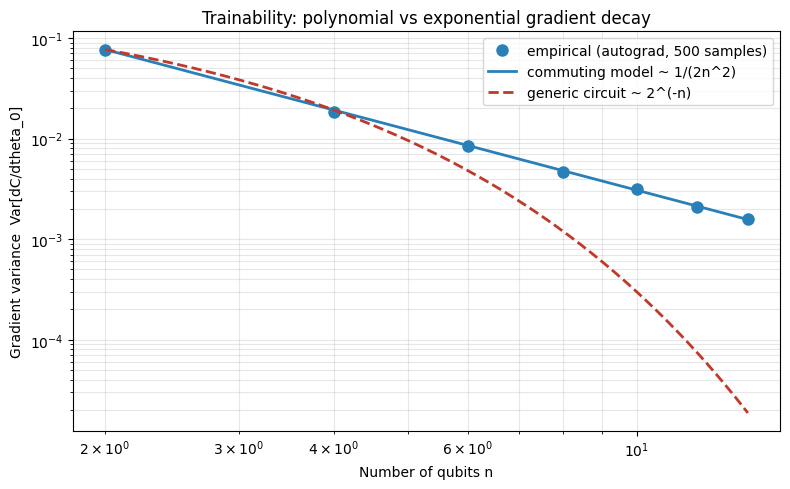

In [20]:
# Plot: gradient variance vs n, on log-log axes.
# Polynomial decay (this commuting model) vs the exponential decay
# ("barren plateau") that generic, non-structured circuits suffer from.

ns_emp = [r[0] for r in trainability_results]
var_emp = [r[1] for r in trainability_results]

n_fine = np.linspace(min(n_list), max(n_list), 200)
theory_curve = np.sin(x_val) ** 2 / (2 * n_fine ** 2)

# Generic-circuit reference ~ 2^(-n), scaled to match the commuting model at n=2
theory_at_n2 = np.sin(x_val) ** 2 / (2 * 2 ** 2)
generic_scale = theory_at_n2 * (2 ** 2)     # so that generic_scale * 2^-2 == theory_at_n2
generic_curve = generic_scale * (2.0 ** (-n_fine))

plt.figure(figsize=(8, 5))
plt.plot(ns_emp, var_emp, 'o', color="#2980b9", markersize=8, label="empirical (autograd, 500 samples)")
plt.plot(n_fine, theory_curve, '-', color="#2980b9", linewidth=2, label="commuting model ~ 1/(2n^2)")
plt.plot(n_fine, generic_curve, '--', color="#c0392b", linewidth=2, label="generic circuit ~ 2^(-n)")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of qubits n")
plt.ylabel("Gradient variance  Var[dC/dtheta_0]")
plt.title("Trainability: polynomial vs exponential gradient decay")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

plt.savefig("trainability_plot.png", dpi=150)
plt.show()
